# OpenDataBattle2026 Phase2 データ加工【空気】- 森林面積

#### [1]読み込み
#### [2]前処理
#### [3]集計

##### 以下3つの指標を採用。
- 森林面積[ha]　2020年
- 総人口　2025年
- 森林面積 / 総人口　（一人当たりの森林面積）

##### ※なお、東京と大阪市の森林面積は
##### 「データが「０」又は指定した単位に満たないことを示している。」
##### とデータに注記されており、森林面積と人口比はそれぞれ0.0となっている。

## 【読み込み】

### ライブラリ読み込み

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 日本語用フォント設定
plt.rcParams["font.family"] = "Meiryo"

### データ読み込み

In [34]:
# 県庁所在地一覧
df_prefectural_capitals = pd.read_csv("../data/raw_00_reference_県庁所在地一覧_20260803.csv", encoding='shift_jis')

# 総人口データ
df_city_population = pd.read_csv("../data/raw_02_atmospheric_県庁所在地別総人口_20260831.csv", skiprows=1)
# 面積データ
df_city_area = pd.read_csv("../data/raw_02_atmospheric_県庁所在地別総面積と森林面積_20260828.csv")

## 【データ確認】

### 県庁所在地一覧データ

In [26]:
# 末尾３件確認
df_prefectural_capitals
    #.tail(3)

,コード,都道府県,県庁所在地,ローマ字
0,1,北海道,札幌市,sapporo
1,2,青森県,青森市,aomori
2,3,岩手県,盛岡市,morioka
3,4,宮城県,仙台市,sendai
4,5,秋田県,秋田市,akita
5,6,山形県,山形市,yamagata
6,7,福島県,福島市,fukushima
7,8,茨城県,水戸市,mito
8,9,栃木県,宇都宮市,utsunomiya
9,10,群馬県,前橋市,maebashi


In [4]:
# 概要
df_prefectural_capitals.info()

<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   コード     47 non-null     int64
 1   都道府県    47 non-null     str  
 2   県庁所在地   47 non-null     str  
 3   ローマ字    47 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.6 KB


### 総人口データ

In [35]:
# 末尾３件
df_city_population.tail(3)

,時点,札幌市,青森市,盛岡市,仙台市,秋田市,山形市,福島市,水戸市,宇都宮市,...,松山市,高知市,福岡市,佐賀市,長崎市,熊本市,大分市,宮崎市,鹿児島市,那覇市
0,2025年,1964034,256180,278636,1096951,293588,235685,265803,265773,511733,...,497041,309383,1663892,227754,381738,730854,470172,389799,580970,311073


In [36]:
# 要約
df_city_population.info()

<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 48 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   時点      1 non-null      str  
 1   札幌市     1 non-null      int64
 2   青森市     1 non-null      int64
 3   盛岡市     1 non-null      int64
 4   仙台市     1 non-null      int64
 5   秋田市     1 non-null      int64
 6   山形市     1 non-null      int64
 7   福島市     1 non-null      int64
 8   水戸市     1 non-null      int64
 9   宇都宮市    1 non-null      int64
 10  前橋市     1 non-null      int64
 11  さいたま市   1 non-null      int64
 12  千葉市     1 non-null      int64
 13  特別区部    1 non-null      int64
 14  横浜市     1 non-null      int64
 15  新潟市     1 non-null      int64
 16  富山市     1 non-null      int64
 17  金沢市     1 non-null      int64
 18  福井市     1 non-null      int64
 19  甲府市     1 non-null      int64
 20  長野市     1 non-null      int64
 21  岐阜市     1 non-null      int64
 22  静岡市     1 non-null      int64
 23  名古屋市    1 non-null      int64


### 面積データ

In [9]:
# 末尾3件
df_city_area.tail(3)

,時点,地域コード,地域,総面積（北方地域及び竹島を除く）【ha】,注記,森林面積【ha】,注記.1
702,2024年,45201,宮崎市,64357.0,NaN,NaN,NaN
703,2024年,46201,鹿児島市,54761.0,NaN,NaN,NaN
704,2024年,47201,那覇市,4146.0,NaN,NaN,NaN


In [10]:
# 要約
df_city_area.info()

<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   時点                    705 non-null    str    
 1   地域コード                 705 non-null    int64  
 2   地域                    705 non-null    str    
 3   総面積（北方地域及び竹島を除く）【ha】  703 non-null    float64
 4   注記                    0 non-null      float64
 5   森林面積【ha】              140 non-null    float64
 6   注記.1                  6 non-null      str    
dtypes: float64(3), int64(1), str(3)
memory usage: 38.7 KB


## 【前処理】

### 県庁所在地データ

In [44]:
### 東京都の県庁所在地が「東京都」になっているので「東京」に変更
df_prefectural_capitals["県庁所在地"] = df_prefectural_capitals["県庁所在地"].replace(
    "東京都", "東京"
)
df_prefectural_capitals["県庁所在地"].unique()

<StringArray>
[  '札幌市',   '青森市',   '盛岡市',   '仙台市',   '秋田市',   '山形市',   '福島市',   '水戸市',
  '宇都宮市',   '前橋市', 'さいたま市',   '千葉市',    '東京',   '横浜市',   '新潟市',   '富山市',
   '金沢市',   '福井市',   '甲府市',   '長野市',   '岐阜市',   '静岡市',  '名古屋市',    '津市',
   '大津市',   '京都市',   '大阪市',   '神戸市',   '奈良市',  '和歌山市',   '鳥取市',   '松江市',
   '岡山市',   '広島市',   '山口市',   '徳島市',   '高松市',   '松山市',   '高知市',   '福岡市',
   '佐賀市',   '長崎市',   '熊本市',   '大分市',   '宮崎市',  '鹿児島市',   '那覇市']
Length: 47, dtype: str

### 総人口データ

In [37]:
# 総人口データが横持ちになっているので転置
df_city_population = df_city_population.T.reset_index()
df_city_population.head(2)

,index,0
0,時点,2025年
1,札幌市,1964034


In [41]:
# 0行目に時点が入ってしまったので形を整える
### 1行目から時点を取得しておく
population_year = df_city_population.iloc[0, 1]
### 2行目以降を都市データとして抽出
df_city_population_2025 = df_city_population.iloc[1:].copy()
### カラム名を変更
df_city_population_2025.columns = ["地域", "総人口"]
### indexを振り直す
df_city_population_2025 = df_city_population_2025.reset_index(drop=True)

df_city_population_2025.head(2)

,地域,総人口
0,札幌市,1964034
1,青森市,256180


###### 面積データの前処理中に発覚した特別区部への変更処理をここでも実行
###### (詳細は次の面積データの前処理ターンで)

In [46]:
# 「特別区部」を「東京」へ変更
df_city_population_2025["地域"] = df_city_population_2025["地域"].replace(
    "特別区部", "東京"
)
# 両向きで完全一致するか確認
set(df_city_population_2025["地域"]) == set(df_prefectural_capitals["県庁所在地"])

True

### 面積データ

In [28]:
# 使う列と森林面積がNaN以外のデータを抽出
df_city_forest = df_city_area[
    df_city_area["森林面積【ha】"].notna()
][["時点", "地域コード", "地域", "森林面積【ha】"]].copy()
df_city_forest.head(2)

,時点,地域コード,地域,森林面積【ha】
0,2010年,1100,札幌市,67724.0
1,2010年,2201,青森市,56122.0


In [29]:
# 年ごとの都市数を確認
df_city_forest.groupby("時点")["地域"].nunique().sort_index(ascending=False)

時点
2020年    47
2015年    47
2010年    46
Name: 地域, dtype: int64

In [30]:
# 2020年が47都市データがあるので採用
df_city_forest_2020 = df_city_forest[
    df_city_forest["時点"] == "2020年"
].reset_index(drop=True).copy()
df_city_forest_2020.head(2)

,時点,地域コード,地域,森林面積【ha】
0,2020年,1100,札幌市,67870.0
1,2020年,2201,青森市,56156.0


In [31]:
# 県庁所在地データの「県庁所在地」と面積データの「地域」一致しているか確認
print("地域にのみあるデータ",
      set(df_city_forest_2020["地域"]) - set(df_prefectural_capitals["県庁所在地"]))
print("県庁所在地にのみあるデータ",
      set(df_prefectural_capitals["県庁所在地"]) - set(df_city_forest_2020["地域"]))

地域にのみあるデータ {'特別区部'}
県庁所在地にのみあるデータ {'東京'}


- 面積データは統計ダッシュボードより「県庁所在地」のみ指定して取得したデータ
- ネット検索より、東京都の東23区を特別区と呼ぶとの情報
##### 上記2点より、「特別区部」を「東京」へ変更処理する

In [32]:
# 「特別区部」を「東京」へ変更
df_city_forest_2020["地域"] = df_city_forest_2020["地域"].replace(
    "特別区部", "東京"
)
# 両向きで完全一致するか確認
set(df_city_forest_2020["地域"]) == set(df_prefectural_capitals["県庁所在地"])

True

### 【集計】

In [51]:
# 総人口と森林面積をマージ
df_forest_population = df_city_forest_2020.merge(
    df_city_population_2025,
    on="地域",
    how="inner"
)
df_forest_population.head(2)

,時点,地域コード,地域,森林面積【ha】,総人口
0,2020年,1100,札幌市,67870.0,1964034
1,2020年,2201,青森市,56156.0,256180


In [54]:
# 一人当たりの森林面積を算出（一万人当たりのものも）
df_forest_population["森林面積_人口比"] = (
    df_forest_population["森林面積【ha】"]
    / df_forest_population["総人口"]
)
df_forest_population["森林面積_1万人あたり"] = (
    df_forest_population["森林面積【ha】"]
    / df_forest_population["総人口"]
    * 10000
)
df_forest_population.head(2)

,時点,地域コード,地域,森林面積【ha】,総人口,森林面積_人口比,森林面積_1万人あたり
0,2020年,1100,札幌市,67870.0,1964034,0.034556,345.564282
1,2020年,2201,青森市,56156.0,256180,0.219205,2192.052463


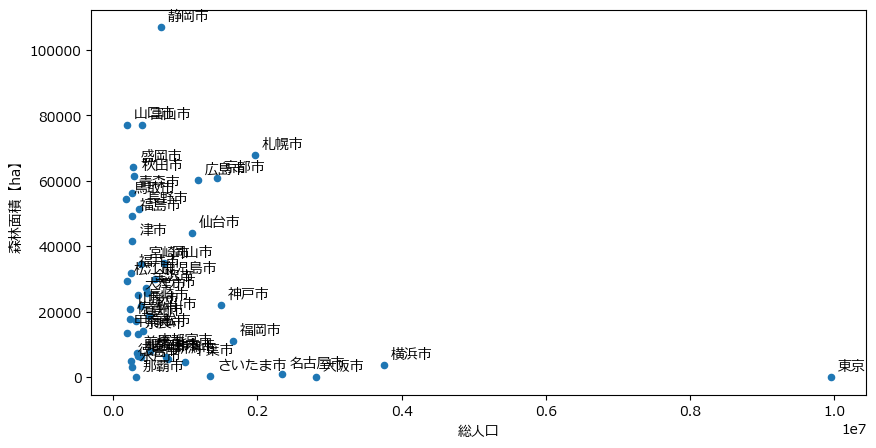

In [63]:
# 総人口と森林面積を散布図でプロット
ax = df_forest_population.plot(
    x="総人口",
    y="森林面積【ha】",
    kind="scatter",
    figsize=(10, 5)
)

# 都市名をラベリング表示
for _, row in df_forest_population.iterrows():
    ax.annotate(
        row["地域"],
        (row["総人口"], row["森林面積【ha】"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.show()

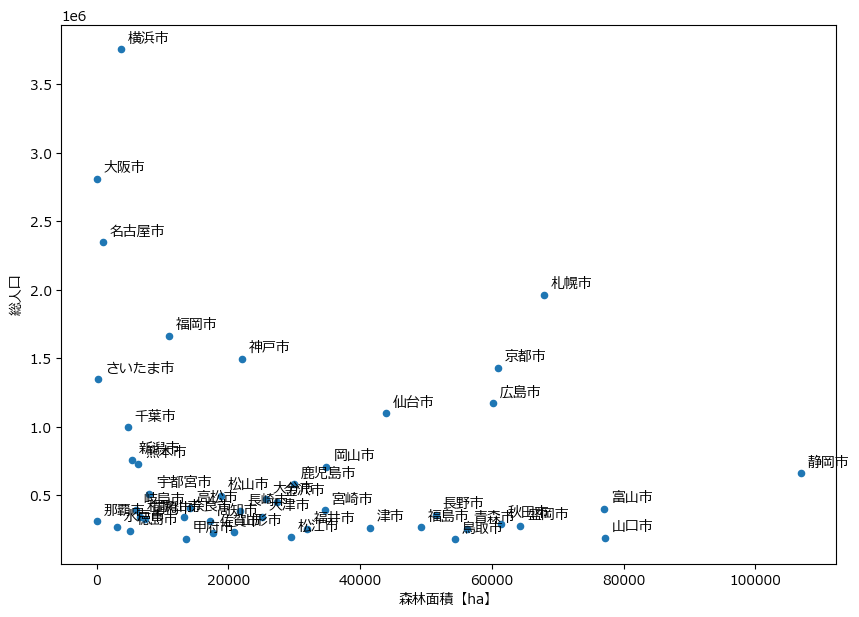

In [65]:
# 東京の人口が突出しているので除外してプロットしてみる　（横軸を森林面積に）
### 東京を除外したデータフレームを作成
df_forest_population_no_tokyo = df_forest_population[
    df_forest_population["地域"] != "東京"
].copy()

### 同様に散布図をプロット
ax = df_forest_population_no_tokyo.plot(
    x="森林面積【ha】",
    y="総人口",
    kind="scatter",
    figsize=(10, 7)
)
for _, row in df_forest_population_no_tokyo.iterrows():
    ax.annotate(
        row["地域"],
        (row["森林面積【ha】"], row["総人口"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.show()

In [66]:
# 不要なカラムを削除
df_forest_population = df_forest_population.drop(
    columns=["時点"]
)

In [69]:
# 集計結果を県庁所在地データにマージ
df_analysis_air_forest = df_prefectural_capitals.merge(
    df_forest_population,
    left_on="県庁所在地",
    right_on="地域",
    how="left"
)
df_analysis_air_forest = df_analysis_air_forest.drop(
    columns=["地域"]
)
df_analysis_air_forest.head(3)

,コード,都道府県,県庁所在地,ローマ字,地域コード,森林面積【ha】,総人口,森林面積_人口比,森林面積_1万人あたり
0,1,北海道,札幌市,sapporo,1100,67870.0,1964034,0.034556,345.564282
1,2,青森県,青森市,aomori,2201,56156.0,256180,0.219205,2192.052463
2,3,岩手県,盛岡市,morioka,3201,64317.0,278636,0.230828,2308.280337


In [71]:
# 集計結果出力
df_analysis_air_forest.to_csv("../data/df_analysis_air_forest.csv", encoding='shift_jis')